# Processing - Vegetation Indices (NASA MODIS)
- 약 5.5 km의 고해상도 자료를 admin2 단위로 병합

## Variables
- NDVI (Normalized Difference Vegetation Index): 식물의 엽록소가 반사하는 빛을 측정합니다. 1에 가까울수록 울창하고, 0에 가까우면 메마른 땅입니다.
$$NDVI = \frac{NIR - RED}{NIR + RED}$$
- EVI (Enhanced Vegetation Index): NDVI의 단점인 대기 노이즈와 빽빽한 숲에서의 수치 포화 현상을 보정한 지수입니다.
- LST (Land Surface Temperature)
- VCI (Vegetation Condition Index): 현재 NDVI가 평년의 최솟값(Min)과 최댓값(Max) 사이에서 어느 위치에 있는지 0~100으로 표현합니다. 30 이하면 과거 기록에 비추어 볼 때 심각한 식생 가뭄이 발생한 것으로 간주합니다.
- TCI (Temperature Condition Index): 현재 LST가 평년의 최솟값(Min)과 최댓값(Max) 사이에서 어느 위치에 있는지 0~100으로 표현합니다.
- VHI (Vegetation Health Index): 식생(VCI)과 온도(TCI) 스트레스를 5:5로 결합한 종합 가뭄 지수입니다. 단순히 풀이 마른 것뿐만 아니라, 지면 온도(LST)가 비정상적으로 높아 식물이 열 스트레스를 받는 상황까지 반영합니다.
$$VHI = 0.5 \times VCI + 0.5 \times TCI$$

## 0. Setting

In [1]:
from pathlib import Path
import logging
import os
import glob

import geopandas as gpd
import rasterio
import rasterio.plot
import rasterio.mask
from rasterstats import zonal_stats

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Configure Logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# Base Data Directory
DATA_DIR = "/content/drive/MyDrive/WFP Collab/subnational_price_prediction/data"

## 1. Load Boundary Files

In [4]:
def load_canonical_boundaries(iso3_list, boundary_dir):
    gdfs = []

    file_map = {
        'KEN': 'gb_KEN_ADM2.geojson',
        'SOM': 'gb_SOM_ADM2.geojson',
        'ETH': 'gb_ETH_ADM2.geojson'
    }

    for iso in iso3_list:
        filename = file_map.get(iso)
        path = os.path.join(boundary_dir, filename)

        if os.path.exists(path):
            try:
                # 1. Load Admin2 (Target Granularity)
                gdf = gpd.read_file(path)

                # Standardize Admin2 Name
                rename_map = {
                    'shapeName_ADM2': 'shapeName',
                    'ADM2_NAME': 'shapeName',
                    'admin2Name': 'shapeName',
                    'shapeName': 'shapeName'
                }
                gdf.rename(columns=rename_map, inplace=True)

                # FIX: Force Populate shapeISO from loop variable
                # GeoJSONs have empty shapeISO, which breaks merges
                gdf['shapeISO'] = iso

                if 'shapeName' not in gdf.columns:
                    logger.warning(f"Could not identify ADM2 name column for {iso}. Available: {gdf.columns.tolist()}")
                    continue

                # 2. Get Admin1 info (Dynamic Spatial Join)
                # Check for sibling ADM1 file
                adm1_filename = filename.replace('ADM2', 'ADM1')
                adm1_path = os.path.join(boundary_dir, adm1_filename)

                if os.path.exists(adm1_path):
                    try:
                        adm1_gdf = gpd.read_file(adm1_path)
                         # Standardize Admin1 Name
                        adm1_rename = {
                            'shapeName': 'admin1',
                            'shapeName_ADM1': 'admin1',
                            'ADM1_NAME': 'admin1'
                        }
                        adm1_gdf.rename(columns=adm1_rename, inplace=True)

                        if 'admin1' in adm1_gdf.columns:
                            # Spatial Join to get Admin1
                            # Ensure CRS match
                            if gdf.crs != adm1_gdf.crs:
                                adm1_gdf = adm1_gdf.to_crs(gdf.crs)

                            # Point on Surface for join guarantees inside
                            # But sjoin works with polygons too.
                            # "inner" or "left" - we want for each ADM2, find its ADM1.
                            # It's better to use centroids if ADM2 boundaries are not perfectly inside ADM1

                            # Use creating centroids for join
                            # But we need to keep geometry of ADM2

                            # Let's use sjoin directly
                            joined = gpd.sjoin(gdf, adm1_gdf[['admin1', 'geometry']], how='left', predicate='intersects')

                            # Handle duplicates if an ADM2 overlaps multiple ADM1s (take mode or first)
                            # Usually taking the one with largest intersection is best, but 'intersects' is binary.
                            # Let's assume clean hierarchy or take first.

                            joined = joined.drop_duplicates(subset=['shapeName'])

                            if 'admin1' in joined.columns:
                                gdf['admin1'] = joined['admin1']
                                logger.info(f"[{iso}] Spatially joined Admin1 info.")
                            else:
                                logger.warning(f"[{iso}] Spatial join failed to add admin1.")
                        else:
                             logger.warning(f"[{iso}] Admin1 file found but no name column.")
                    except Exception as e:
                        logger.warning(f"[{iso}] Failed to process Admin1 file: {e}")
                else:
                    logger.warning(f"[{iso}] No Admin1 reference file found at {adm1_path}")

                gdfs.append(gdf)
                logger.info(f"Loaded {iso} boundaries. Rows: {len(gdf)}")

            except Exception as e:
                logger.error(f"Failed to load {iso}: {e}")

    if not gdfs:
        return gpd.GeoDataFrame()

    full_gdf = pd.concat(gdfs, ignore_index=True)
    return full_gdf

In [5]:
# Parameters
iso3_list = ['KEN', 'SOM', 'ETH']
boundary_dir = os.path.join(DATA_DIR, 'geoboundaries')

admin_gdf = load_canonical_boundaries(iso3_list, boundary_dir)
if not admin_gdf.empty:
    canonical_names = admin_gdf['shapeName'].unique().tolist()
    print(f"Loaded {len(admin_gdf)} total regions.")
    print(admin_gdf.head())
else:
    print("No boundaries loaded! Check file paths.")

Loaded 482 total regions.
      shapeName shapeISO                 shapeID shapeGroup shapeType  \
0      Ainabkoi      KEN  3690345B95414198105650        KEN      ADM2   
1       Ainamoi      KEN  3690345B54801368411234        KEN      ADM2   
2         Aldai      KEN  3690345B36924206491537        KEN      ADM2   
3  Alego Usonga      KEN  3690345B57306569752992        KEN      ADM2   
4        Awendo      KEN  3690345B13715496647196        KEN      ADM2   

                                            geometry       admin1  
0  POLYGON ((35.4633 0.5072, 35.46246 0.50691, 35...  Uasin Gishu  
1  POLYGON ((35.32495 -0.25056, 35.3225 -0.24841,...      Kericho  
2  POLYGON ((35.13034 0.1363, 35.12748 0.13635, 3...       Kisumu  
3  POLYGON ((34.21848 0.16479, 34.21677 0.1634, 3...        Siaya  
4  POLYGON ((34.62157 -0.9854, 34.61932 -0.9833, ...       Migori  


## 2. Check Metadata

In [ ]:
def check_raster_metadata(file_path):
    # 1. 파일 경로 설정 (폴더 경로와 연도 확인)
    files = glob.glob(file_path)

    if not files:
        print(f"❌ 파일을 찾을 수 없습니다. 경로를 확인해 주세요.")
    else:
        sample_file = files[0]
        print(f"📂 분석 대상 파일: {os.path.basename(sample_file)}\n")

        # 2. Rasterio로 메타데이터 읽기
        with rasterio.open(sample_file) as src:
            num_bands = src.count
            print(f"📊 총 밴드 개수: {num_bands}개\n")

            # 3. 밴드별 이름(Description) 추출
            # 보통 GEE에서 Export할 때 밴드 이름이 descriptions에 저장됩니다.
            descriptions = src.descriptions

            # 4. 첫 달의 변수 리스트 자동 추출
            if descriptions[0]:
                # '_'를 기준으로 쪼개서 뒤쪽 변수명만 가져오기 (예: '0_NDVI' -> 'NDVI')
                try:
                    # 첫 달(보통 1월)에 해당하는 변수 개수가 몇 개인지 찾기
                    first_month_prefix = descriptions[0].split('_')[0]
                    first_month_vars = []
                    for name in descriptions:
                        if name and name.startswith(first_month_prefix + '_'):
                            first_month_vars.append(name.split('_', 1)[1])
                    print(f"-> 변수 리스트 생성 완료 ({len(first_month_vars)}개)")
                except Exception as e:
                    print("-> 변수명 패턴이 예상과 다릅니다. 위 목록을 직접 확인해 주세요.")

    return first_month_vars

In [ ]:
# Vegetation
vegetation_check_file = os.path.join(DATA_DIR, 'vegetation/raw/EastAfrica_Vegetation_Indices_2025_5km.tif')
vegetation_vars = check_raster_metadata(vegetation_check_file)

📂 분석 대상 파일: EastAfrica_Vegetation_Indices_2025_5km.tif

📊 총 밴드 개수: 72개

-> 변수 리스트 생성 완료 (6개)


In [ ]:
vegetation_vars

['NDVI', 'EVI', 'LST', 'VCI', 'TCI', 'VHI']

## 3. Processing Data

In [ ]:
def extract_zonal_timeseries(gdf, tiff_dir, tiff_pattern, variables, year_start, year_end):
    """
    GeoTIFF 파일들을 읽어 행정구역별 월별 평균 시계열 데이터프레임으로 변환합니다.
    """
    print("🚀 구역 통계(Zonal Statistics) 및 시계열 변환을 시작합니다...")

    # 최종 결과를 담을 리스트
    all_records = []

    # 원본 GDF에서 필요한 식별자 컬럼만 추출 후 이름 변경 (사용자 요청 포맷)
    # 동료 코드의 결과물(gdf) 기준: shapeISO, admin1, shapeName
    base_df = gdf[['shapeISO', 'admin1', 'shapeName', 'geometry']].copy()
    base_df = base_df.rename(columns={
        'shapeISO': 'country_iso',
        'shapeName': 'admin2'
    })

    # 연도별로 생성된 GeoTIFF 파일 순회
    for year in range(year_start, year_end + 1):
        # 파일명 패턴 찾기 (예: *_2007_5km.tif)
        pattern = os.path.join(tiff_dir, tiff_pattern.format(year))
        files = glob.glob(pattern)

        if not files:
            print(f"⚠️ {year}년 파일을 찾을 수 없어 건너뜁니다.")
            continue

        target_file = files[0]
        print(f"🔄 처리 중: {os.path.basename(target_file)}")

        # 1. Rasterio를 통해 데이터 메타정보 읽기
        with rasterio.open(target_file) as src:
            transform = src.transform
            array = src.read() # 전체 밴드를 메모리에 로드 (5km라 가벼움)

        # 2. 월별(1~12월) 데이터 추출
            for month in range(1, 13):
            # 임시 데이터프레임 생성 (해당 연도/월 정보 추가)
                month_df = base_df.drop(columns='geometry').copy()
                month_df.insert(0, 'year', year)
                month_df.insert(1, 'month', month)

            # 3. 변수별 밴드 인덱스 매칭 및 Zonal Statistics 계산
                for v_idx, var_name in enumerate(variables):
                    # GEE에서 월별로 변수가 묶여서 밴드로 저장됨
                # 예: 1월 변수 6개, 2월 변수 6개...
                # 밴드 인덱스는 0부터 시작하므로: (월 - 1) * 변수개수 + 변수순서
                    band_idx = (month - 1) * len(variables) + v_idx

                # 해당 밴드의 2D 배열 추출
                    band_data = array[band_idx]

                # [핵심] Zonal Statistics (행정구역별 픽셀 평균값 계산)
                    # stats = zonal_stats(
                    #     vectors=base_df['geometry'],
                    #     raster=band_data,
                    #     affine=transform,
                    #     stats="mean",
                    #     nodata=0,
                    #     all_touched=True
                    # )
                    stats = zonal_stats(
                        vectors=base_df['geometry'],
                        raster=band_data,
                        affine=transform,
                        stats="mean",
                        nodata=-9999, # <--- [핵심] 이렇게 해야 바다 픽셀을 평균 계산에서 완벽히 제외합니다.
                        all_touched=True  # all_touched=True: 다각형 경계에 걸친 픽셀도 포함하여 누락 방지
                    )

                # 계산된 평균값을 변수명 컬럼으로 추가
                    month_df[var_name] = [s['mean'] for s in stats]

            # 추출된 한 달 치 데이터를 전체 리스트에 추가
                all_records.append(month_df)

    # 4. 전체 데이터를 하나의 데이터프레임으로 병합
    if not all_records:
        return pd.DataFrame()

    final_df = pd.concat(all_records, ignore_index=True)

    # 정렬 (국가 -> 도 -> 시군구 -> 연도 -> 월)
    final_df = final_df.sort_values(['country_iso', 'admin1', 'admin2', 'year', 'month']).reset_index(drop=True)

    print(f"✅ 변환 완료! 총 {len(final_df)}행의 패널 데이터가 생성되었습니다.")
    return final_df

In [ ]:
# Vegetation
input_folder = Path(DATA_DIR) / 'vegetation' / 'raw'
input_pattern = "EastAfrica_Vegetation_Indices_{}_5km.tif"

output_folder = Path(DATA_DIR) / 'vegetation' / 'processed'
output_folder.mkdir(parents=True, exist_ok=True)
output_path = output_folder / 'EastAfrica_Vegetation_Indices_2007_2025.csv'

output_df = extract_zonal_timeseries(admin_gdf, input_folder, input_pattern, vegetation_vars, 2007, 2025)
output_df.to_csv(output_path, index=False)

🚀 구역 통계(Zonal Statistics) 및 시계열 변환을 시작합니다...
🔄 처리 중: EastAfrica_Vegetation_Indices_2007_5km.tif
🔄 처리 중: EastAfrica_Vegetation_Indices_2008_5km.tif
🔄 처리 중: EastAfrica_Vegetation_Indices_2009_5km.tif
🔄 처리 중: EastAfrica_Vegetation_Indices_2010_5km.tif
🔄 처리 중: EastAfrica_Vegetation_Indices_2011_5km.tif
🔄 처리 중: EastAfrica_Vegetation_Indices_2012_5km.tif
🔄 처리 중: EastAfrica_Vegetation_Indices_2013_5km.tif
🔄 처리 중: EastAfrica_Vegetation_Indices_2014_5km.tif
🔄 처리 중: EastAfrica_Vegetation_Indices_2015_5km.tif
🔄 처리 중: EastAfrica_Vegetation_Indices_2016_5km.tif
🔄 처리 중: EastAfrica_Vegetation_Indices_2017_5km.tif
🔄 처리 중: EastAfrica_Vegetation_Indices_2018_5km.tif
🔄 처리 중: EastAfrica_Vegetation_Indices_2019_5km.tif
🔄 처리 중: EastAfrica_Vegetation_Indices_2020_5km.tif
🔄 처리 중: EastAfrica_Vegetation_Indices_2021_5km.tif
🔄 처리 중: EastAfrica_Vegetation_Indices_2022_5km.tif
🔄 처리 중: EastAfrica_Vegetation_Indices_2023_5km.tif
🔄 처리 중: EastAfrica_Vegetation_Indices_2024_5km.tif
🔄 처리 중: EastAfrica_Vegetation_Indices

## 4. Sanity Check

In [6]:
# ==========================================
# 1. 파일 로드 (저장하신 파일명으로 수정하세요)
# ==========================================
file_path =  Path(DATA_DIR) / 'vegetation' / 'processed' / 'EastAfrica_Vegetation_Indices_2007_2025.csv'
df = pd.read_csv(file_path)

print("--- [1] 기본 정보 확인 ---")
print(f"✅ 데이터 건수: {len(df):,}행")
print(f"✅ 컬럼 목록: {df.columns.tolist()}")

--- [1] 기본 정보 확인 ---
✅ 데이터 건수: 109,896행
✅ 컬럼 목록: ['year', 'month', 'country_iso', 'admin1', 'admin2', 'NDVI', 'EVI', 'LST', 'VCI', 'TCI', 'VHI']


In [ ]:
# ==========================================
# 2. 결측치(NaN) 및 지리적/시간적 완전성 확인
# ==========================================
print("--- [2] 결측치 및 고유값 확인 ---")

# 결측치 개수
missing_vals = df.isnull().sum()
if missing_vals.sum() == 0:
    print("✅ 결측치(NaN)가 하나도 없습니다! (완벽합니다)")
else:
    print("⚠️ 일부 컬럼에 결측치가 있습니다:")
    print(missing_vals[missing_vals > 0])
    missing_vals2 = df.isnull().sum(axis=1)
    print("⚠️ 결측치가 가장 많은 레코드:")
    print(df.iloc[missing_vals2.argmax()])

# 연도 및 월 확인 (12개월이 꽉 차 있는지)
print(f"✅ 포함된 연도: {df['year'].unique().tolist()}")
print(f"✅ 포함된 월: {df['month'].unique().tolist()} (1~12월 모두 있어야 함)")

# 행정구역 개수 확인
print(f"✅ 대상 국가: {df['country_iso'].unique().tolist()}")
print(f"✅ Admin1(도) 개수: {df['admin1'].nunique()}개")
print(f"✅ Admin2(시군구) 개수: {df['admin2'].nunique()}개")

--- [2] 결측치 및 고유값 확인 ---
✅ 결측치(NaN)가 하나도 없습니다! (완벽합니다)
✅ 포함된 연도: [2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
✅ 포함된 월: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12] (1~12월 모두 있어야 함)
✅ 대상 국가: ['ETH', 'KEN', 'SOM']
✅ Admin1(도) 개수: 71개
✅ Admin2(시군구) 개수: 482개


In [ ]:
# ==========================================
# 3. 변수별 통계량 확인 (Value Ranges)
# ==========================================
print("--- [3] 주요 변수 통계량 확인 ---")

# 검증할 식생/기후 변수들만 선택 (본인 데이터에 맞게 수정)
target_vars = [col for col in df.columns if col not in ['year', 'month', 'country_iso', 'admin1', 'admin2']]

# 요약 통계 출력
summary = df[target_vars].describe().T[['min', 'max', 'mean']]
print(summary.round(3))

--- [3] 주요 변수 통계량 확인 ---
         min      max    mean
NDVI   0.052    0.883   0.472
EVI    0.050    0.671   0.291
LST   14.153   50.332  31.848
VCI    0.000  100.000  50.287
TCI    0.000  100.000  54.910
VHI    0.000  100.000  52.600


--- [4] 특정 지역 시계열 시각화 검증 ---


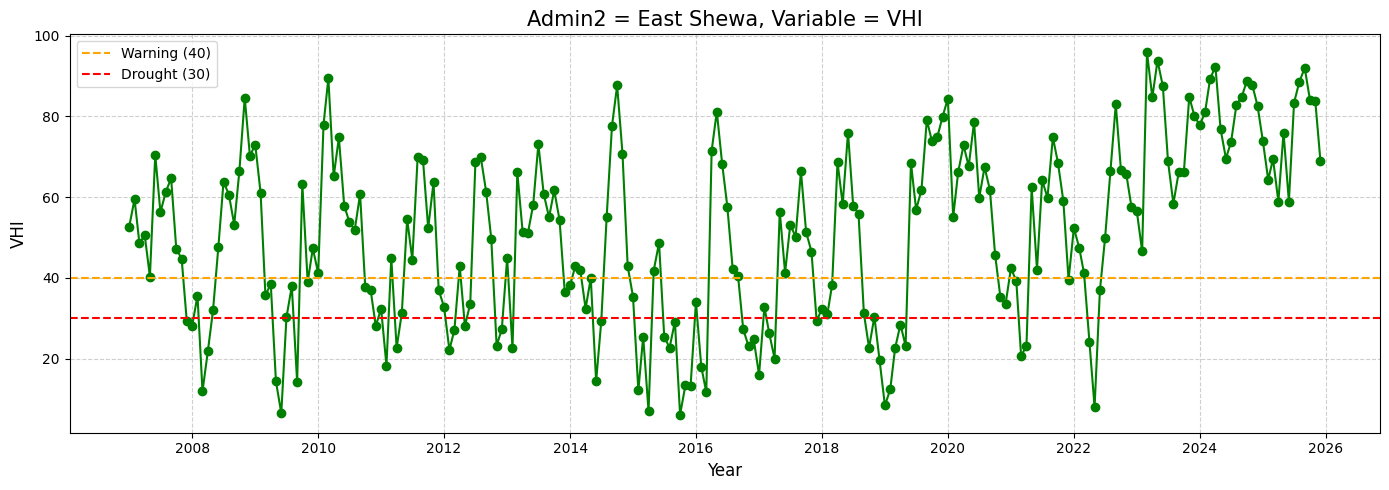

✅ 시각화 완료: East Shewa 지역의 데이터가 연도/월별로 끊김 없이 잘 이어지는지 확인하세요.


In [ ]:
# ==========================================
# 4. 시계열 그래프 시각화 검증 (랜덤 1개 지역)
# ==========================================
print("--- [4] 특정 지역 시계열 시각화 검증 ---")
# 임의의 한 지역(Admin2) 선택
sample_region = df['admin2'].dropna().unique()[0]
sample_df = df[df['admin2'] == sample_region].copy()

# 날짜 컬럼 생성 (그래프용)
sample_df['date'] = pd.to_datetime(sample_df['year'].astype(str) + '-' + sample_df['month'].astype(str) + '-01')
sample_df = sample_df.sort_values('date')

# VHI(또는 특정 변수) 그리기
plot_var = 'VHI' if 'VHI' in target_vars else target_vars[0]

plt.figure(figsize=(14, 5))
plt.plot(sample_df['date'], sample_df[plot_var], marker='o', linestyle='-', color='g')
plt.title(f"Admin2 = {sample_region}, Variable = {plot_var}", fontsize=15)
plt.xlabel("Year", fontsize=12)
plt.ylabel(plot_var, fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# VHI 기준선 추가 (가뭄 판단 기준 30/40)
if plot_var == 'VHI':
    plt.axhline(y=40, color='orange', linestyle='--', label='Warning (40)')
    plt.axhline(y=30, color='red', linestyle='--', label='Drought (30)')
    plt.legend()

plt.tight_layout()
plt.show()

print(f"✅ 시각화 완료: {sample_region} 지역의 데이터가 연도/월별로 끊김 없이 잘 이어지는지 확인하세요.")

## 5. Functionality Check

In [9]:
# ==========================================
# 1. 파일 경로 설정 (사용자 환경에 맞게 수정)
# ==========================================
tiff_file = Path(DATA_DIR) / 'vegetation' / 'raw' / 'EastAfrica_Vegetation_Indices_2025_5km.tif'
target_gdf = admin_gdf.copy()

# [핵심] 면적 계산을 위해 임시로 평면(투영) 좌표계로 변환 (EPSG:6933은 전 지구 면적 계산용 표준)
# geometry.area는 제곱미터(m²) 단위이므로 10^6으로 나누어 제곱킬로미터(km²)로 바꿉니다.
target_gdf['area_sq_km'] = target_gdf.to_crs('EPSG:6933').geometry.area / (10**6)

# 면적이 큰 순서대로 정렬
sorted_gdf = target_gdf.sort_values(by='area_sq_km', ascending=False)

# 상위 5개 넓은 지역 출력해서 확인하기
print("🏆 [가장 면적이 넓은 지역 Top 5]")
top5 = sorted_gdf[['shapeISO', 'admin1', 'shapeName', 'area_sq_km']].head(5)
print(top5.to_string(index=False))

🏆 [가장 면적이 넓은 지역 Top 5]
shapeISO           admin1    shapeName   area_sq_km
     ETH           Somali        Afder 62044.027130
     ETH           Somali         Bale 54644.122277
     ETH           Somali        Doolo 52462.468174
     ETH           Somali       Borena 52436.722485
     ETH Beneshangul Gumu North Gonder 42907.394764


🔍 검증 대상 지역: Afder
✅ 좌표계(CRS)가 정확히 일치합니다.


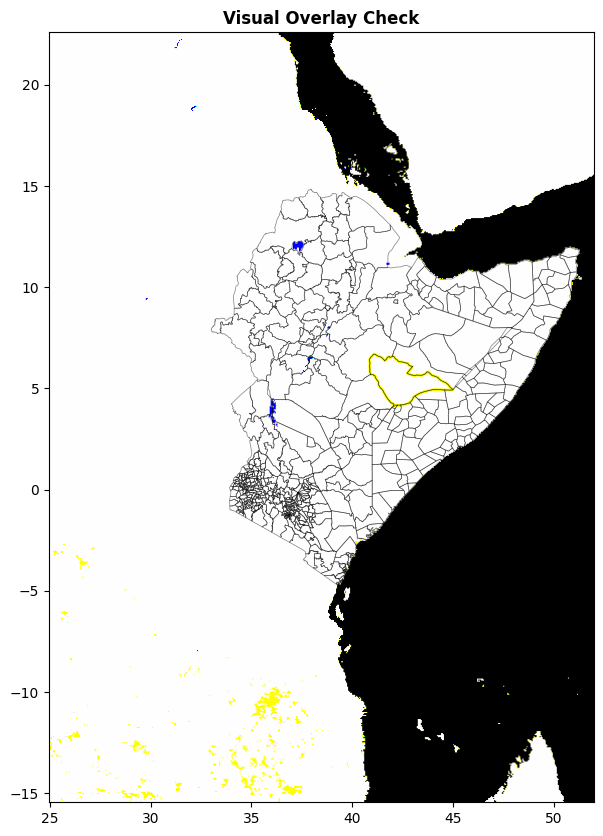

💡 [체크포인트] 노란색 테두리(샘플 지역)와 빨간선들이 색깔이 있는 픽셀들과 딱 맞게 겹치나요?


In [10]:
# 가장 넓은 지역을 검증할 타겟 지역으로 선정
# (만약 1등 말고 2등을 하고 싶다면 iloc[1]로 바꾸시면 됩니다)
sample_region_name = sorted_gdf.iloc[0]['shapeName']
sample_polygon = target_gdf[target_gdf['shapeName'] == sample_region_name]

print(f"🔍 검증 대상 지역: {sample_region_name}")

# ==========================================
# 2. 시각적 검증 (Raster 위에 Polygon 얹기)
# ==========================================
with rasterio.open(tiff_file) as src:
    # 좌표계(CRS) 일치 여부 확인
    if src.crs != sample_polygon.crs:
        print(f"⚠️ 경고: 좌표계가 다릅니다! (Raster: {src.crs}, Vector: {sample_polygon.crs})")
        sample_polygon = sample_polygon.to_crs(src.crs)
    else:
        print("✅ 좌표계(CRS)가 정확히 일치합니다.")

    # 그래프 그리기
    fig, ax = plt.subplots(figsize=(10, 10))

    # 위성 데이터 첫 번째 밴드 시각화
    rasterio.plot.show(src, ax=ax, cmap='viridis', title="Visual Overlay Check")

    # 전체 행정구역 경계선 그리기
    target_gdf.boundary.plot(ax=ax, color='black', linewidth=0.5, alpha=0.5)

    # 샘플로 선택한 1개 지역만 눈에 띄게 칠하기 (노란색)
    sample_polygon.plot(ax=ax, facecolor='none', edgecolor='yellow', linewidth=2)

    plt.show()
    print("💡 [체크포인트] 노란색 테두리(샘플 지역)와 빨간선들이 색깔이 있는 픽셀들과 딱 맞게 겹치나요?")

In [12]:
# ==========================================
# 3. 수동 샘플링 검증 (직접 마스킹하여 평균 계산)
# ==========================================
with rasterio.open(tiff_file) as src:
    # [핵심] 폴리곤 모양대로 픽셀 오려내기
    # CSV 추출 때 all_touched=True를 썼으므로, 여기서도 반드시 True로 해야 값이 일치합니다.
    out_image, out_transform = rasterio.mask.mask(
        src,
        sample_polygon.geometry,
        crop=True,
        all_touched=True ,
        nodata=-9999
    )

    # 밴드 이름(Description) 리스트 가져오기
    descriptions = src.descriptions

    print("-" * 55)
    print(f"{'Band Name':<35} | {'Manual Mean':<15}")
    print("-" * 55)

    # 모든 밴드(월별/변수별)를 순회하며 계산
    for i in range(src.count):
        band_data = out_image[i]

        # 밴드 이름 매칭 (이름이 없으면 Band 번호로 출력)
        band_name = descriptions[i]
        if not band_name:
            band_name = f"Band_{i+1}"

        # 결측치(-9999) 및 NaN을 제외하고 유효한 픽셀만 추출
        nodata_val = src.nodata if src.nodata is not None else -9999
        valid_pixels = band_data[(band_data != nodata_val) & (~np.isnan(band_data))]

        if len(valid_pixels) == 0:
            print(f"{band_name:<35} | {'No Valid Data':<15}")
        else:
            # 수동 평균 계산
            manual_mean = valid_pixels.mean()
            print(f"{band_name:<35} | {manual_mean:10.4f}")

    print("-" * 55)

-------------------------------------------------------
Band Name                           | Manual Mean    
-------------------------------------------------------
216_NDVI                            |     0.2695
216_EVI                             |     0.1475
216_LST                             |    35.5775
216_VCI                             |    45.5804
216_TCI                             |    99.5803
216_VHI                             |    72.5803
217_NDVI                            |     0.2279
217_EVI                             |     0.1301
217_LST                             |    37.5896
217_VCI                             |    50.0735
217_TCI                             |    99.8977
217_VHI                             |    74.9856
218_NDVI                            |     0.3023
218_EVI                             |     0.1815
218_LST                             |    37.0153
218_VCI                             |    45.7049
218_TCI                             |    85.3080
2

In [13]:
df.loc[(df['year'] == 2025) & (df['admin2'] == sample_region_name)].T

,13212,13213,13214,13215,13216,13217,13218,13219,13220,13221,13222,13223
year,2025,2025,2025,2025,2025,2025,2025,2025,2025,2025,2025,2025
month,1,2,3,4,5,6,7,8,9,10,11,12
country_iso,ETH,ETH,ETH,ETH,ETH,ETH,ETH,ETH,ETH,ETH,ETH,ETH
admin1,Somali,Somali,Somali,Somali,Somali,Somali,Somali,Somali,Somali,Somali,Somali,Somali
admin2,Afder,Afder,Afder,Afder,Afder,Afder,Afder,Afder,Afder,Afder,Afder,Afder
NDVI,0.269527,0.227878,0.302326,0.427707,0.418627,0.270644,0.215541,0.232496,0.226296,0.359231,0.342843,0.255868
EVI,0.147462,0.130089,0.181532,0.285737,0.269973,0.172405,0.138286,0.135273,0.140285,0.220944,0.208379,0.148501
LST,35.577532,37.589612,37.015309,30.277954,31.439314,31.647918,31.466381,33.527514,36.452644,33.391444,34.719256,34.35435
VCI,45.580366,50.073455,45.704885,71.660216,65.035862,47.597468,49.948305,71.38245,40.98213,54.132726,35.655905,15.960456
TCI,99.580295,99.89768,85.308024,95.735845,90.445445,92.979224,98.941783,99.630891,99.05477,73.965345,60.233103,91.675977
